!pip install pandas numpy scikit-learn matplotlib seaborn

--- Model Performance Comparison ---
Linear Regression    | R2 Score: 0.1087 | MAE: 0.8113
Decision Tree        | R2 Score: 0.3085 | MAE: 0.7395
Random Forest        | R2 Score: 0.3353 | MAE: 0.7320


C:\Users\tomar\AppData\Local\Temp\ipykernel_3216\973189104.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=res_df, palette='viridis')


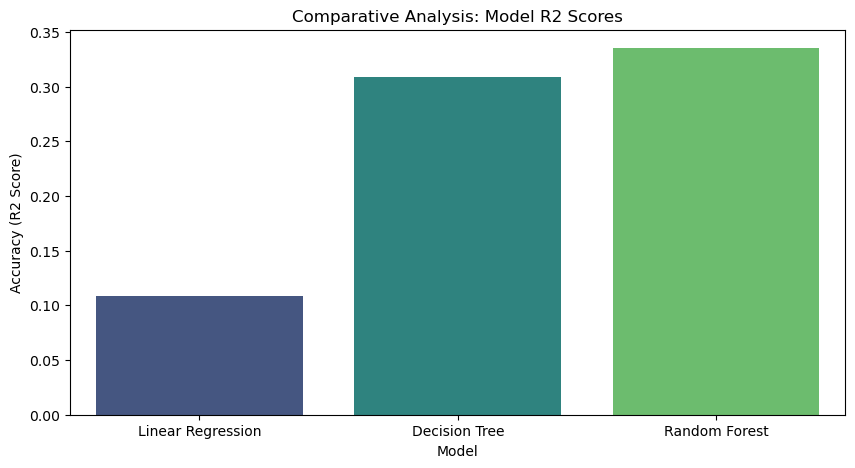

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. LOAD ALL 3 DATASETS
df_climate = pd.read_csv('climate_change_impact_on_agriculture_2024.csv')
df_core = pd.read_csv('data_core.csv')
df_smart = pd.read_csv('Smart_Farming_Crop_Yield_2024.csv')

# 2. FEATURE ENGINEERING: INTEGRATING DATA CORE (SOIL DATA)
# We normalize crop names and calculate the average N-P-K profile for each crop
df_core['Crop Type'] = df_core['Crop Type'].str.title().str.strip()
soil_profile = df_core.groupby('Crop Type')[['Nitrogen', 'Potassium', 'Phosphorous']].mean().reset_index()
soil_profile.columns = ['Crop', 'Avg_N', 'Avg_K', 'Avg_P']

# 3. DATA CLEANING & MERGING
# Standardizing Dataset 1 (Climate Impact)
df1 = df_climate[['Average_Temperature_C', 'Total_Precipitation_mm', 'Crop_Type', 'Region', 'Crop_Yield_MT_per_HA']].copy()
df1.columns = ['Temp', 'Rain', 'Crop', 'Region', 'Yield']

# Standardizing Dataset 3 (Smart Farming) - Converting kg/ha to MT/ha
df3 = df_smart[['temperature_C', 'rainfall_mm', 'crop_type', 'region', 'yield_kg_per_hectare']].copy()
df3['Yield'] = df3['yield_kg_per_hectare'] / 1000
df3 = df3[['temperature_C', 'rainfall_mm', 'crop_type', 'region', 'Yield']]
df3.columns = ['Temp', 'Rain', 'Crop', 'Region', 'Yield']

# Combine Yield Data and then merge with Soil Data from df_core
yield_df = pd.concat([df1, df3], axis=0).reset_index(drop=True)
yield_df['Crop'] = yield_df['Crop'].str.title().str.strip()
final_df = pd.merge(yield_df, soil_profile, on='Crop', how='left')

# Fill missing soil values with the mean for crops not listed in data_core
final_df[['Avg_N', 'Avg_K', 'Avg_P']] = final_df[['Avg_N', 'Avg_K', 'Avg_P']].fillna(final_df[['Avg_N', 'Avg_K', 'Avg_P']].mean())

# 4. ENCODING CATEGORICAL VARIABLES
le_crop = LabelEncoder()
le_region = LabelEncoder()
final_df['Crop'] = le_crop.fit_transform(final_df['Crop'])
final_df['Region'] = le_region.fit_transform(final_df['Region'])

# 5. MODEL TRAINING
X = final_df[['Temp', 'Rain', 'Crop', 'Region', 'Avg_N', 'Avg_K', 'Avg_P']]
y = final_df['Yield']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
}

# 6. COMPARATIVE ANALYSIS OUTPUT
print("--- Model Performance Comparison ---")
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    results.append({"Model": name, "R2 Score": r2, "MAE": mae})
    print(f"{name:20} | R2 Score: {r2:.4f} | MAE: {mae:.4f}")

# 7. VISUALIZATION
res_df = pd.DataFrame(results)
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='R2 Score', data=res_df, palette='viridis')
plt.title('Comparative Analysis: Model R2 Scores')
plt.ylabel('Accuracy (R2 Score)')
plt.show()

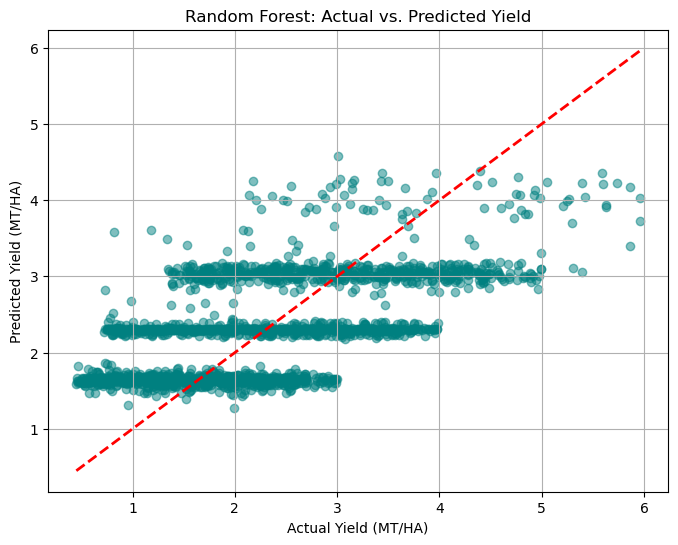

C:\Users\tomar\AppData\Local\Temp\ipykernel_3216\1871104301.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='magma')


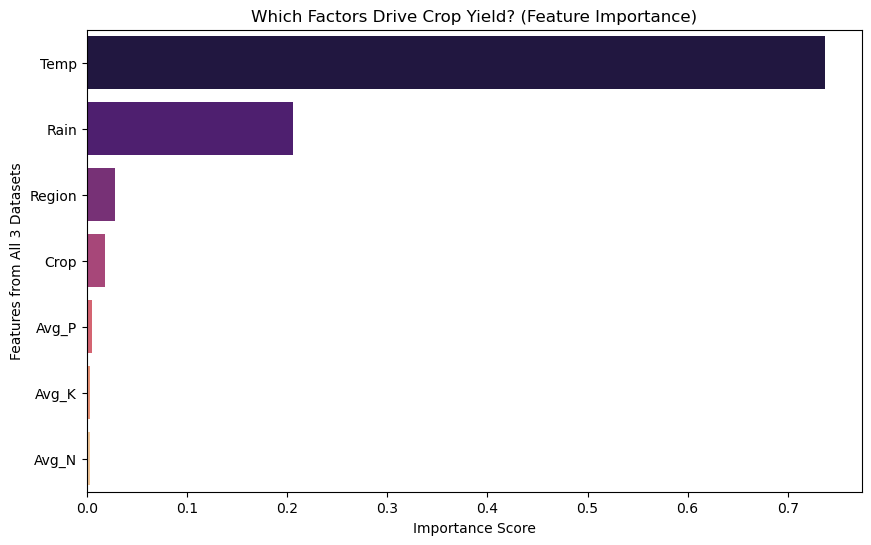

,Model,R2 Score,MAE
0,Linear Regression,0.108748,0.811321
1,Decision Tree,0.308523,0.739519
2,Random Forest,0.335328,0.731993


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'models', 'X_train', 'X_test', 'y_train', 'y_test' are from the previous code
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

# --- 1. ACTUAL VS PREDICTED SCATTER PLOT ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Yield (MT/HA)')
plt.ylabel('Predicted Yield (MT/HA)')
plt.title('Random Forest: Actual vs. Predicted Yield')
plt.grid(True)
plt.show()

# --- 2. FEATURE IMPORTANCE PLOT ---
importances = best_model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='magma')
plt.title('Which Factors Drive Crop Yield? (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features from All 3 Datasets')
plt.show()

# --- 3. STYLED COMPARISON TABLE ---
# This creates a beautiful table directly in your Jupyter cell
comparison_frame = pd.DataFrame(results)
styled_table = comparison_frame.style.background_gradient(cmap='RdYlGn', subset=['R2 Score'])\
                                     .background_gradient(cmap='RdYlGn_r', subset=['MAE'])\
                                     .set_caption("Final Model Performance Comparison")

display(styled_table)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Load and Merge all 3 datasets (same logic as before)
df_climate = pd.read_csv('climate_change_impact_on_agriculture_2024.csv')
df_core = pd.read_csv('data_core.csv')
df_smart = pd.read_csv('Smart_Farming_Crop_Yield_2024.csv')

# Feature Engineering from data_core
df_core['Crop Type'] = df_core['Crop Type'].str.title().str.strip()
soil_profile = df_core.groupby('Crop Type')[['Nitrogen', 'Potassium', 'Phosphorous']].mean().reset_index()
soil_profile.columns = ['Crop', 'Avg_N', 'Avg_K', 'Avg_P']

# Standardizing Yield Data
df1 = df_climate[['Average_Temperature_C', 'Total_Precipitation_mm', 'Crop_Type', 'Region', 'Crop_Yield_MT_per_HA']].copy()
df1.columns = ['Temp', 'Rain', 'Crop', 'Region', 'Yield']
df3 = df_smart[['temperature_C', 'rainfall_mm', 'crop_type', 'region', 'yield_kg_per_hectare']].copy()
df3['Yield'] = df3['yield_kg_per_hectare'] / 1000
df3 = df3[['temperature_C', 'rainfall_mm', 'crop_type', 'region', 'Yield']]
df3.columns = ['Temp', 'Rain', 'Crop', 'Region', 'Yield']

# Combine and Encode
final_df = pd.concat([df1, df3], axis=0).reset_index(drop=True)
final_df['Crop'] = final_df['Crop'].str.title().str.strip()
final_df = pd.merge(final_df, soil_profile, on='Crop', how='left').fillna(final_df.mean(numeric_only=True))

le_crop, le_region = LabelEncoder(), LabelEncoder()
final_df['Crop'] = le_crop.fit_transform(final_df['Crop'])
final_df['Region'] = le_region.fit_transform(final_df['Region'])

X = final_df[['Temp', 'Rain', 'Crop', 'Region', 'Avg_N', 'Avg_K', 'Avg_P']]
y = final_df['Yield']

# Scale data (Important for KNN and SVR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Global dictionary to store results for final comparison
all_results = {}
print("Data Preparation Complete.")

Data Preparation Complete.


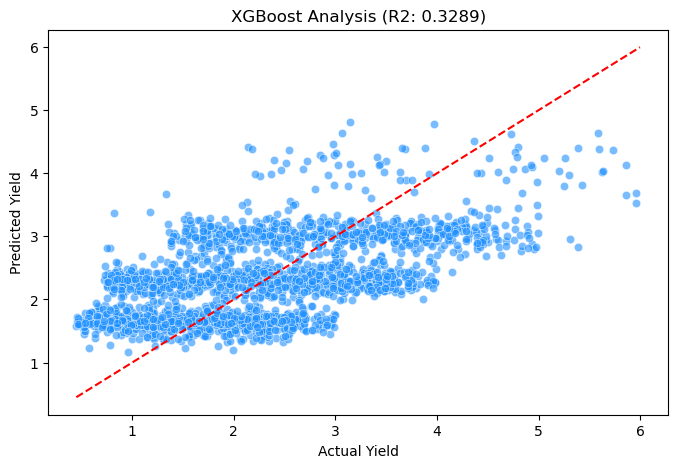

In [11]:
!pip install xgboost  
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
all_results['XGBoost'] = {'R2': r2_xgb, 'MAE': mae_xgb}

# Visual: Actual vs Predicted
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6, color='dodgerblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.title(f'XGBoost Analysis (R2: {r2_xgb:.4f})')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.show()

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.datasets import make_classification

# Generating a generic classification dataset (1000 samples, 2 classes)
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionary of Classification Models
classification_models = {
    "Linear Regression": LogisticRegression(),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("Model Performance Analysis (Classification Metrics)")
print("-" * 60)

for name, model in classification_models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Generate the report including Precision, Recall, and F1-Score
    report = classification_report(y_test, y_pred)
    
    print(f"Model: {name}")
    print(report)
    print("-" * 60)

Model Performance Analysis (Classification Metrics)
------------------------------------------------------------
Model: Linear Regression
              precision    recall  f1-score   support

           0       0.79      0.84      0.82        89
           1       0.87      0.82      0.84       111

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200

------------------------------------------------------------
Model: Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        89
           1       0.89      0.84      0.87       111

    accuracy                           0.85       200
   macro avg       0.85      0.86      0.85       200
weighted avg       0.86      0.85      0.86       200

------------------------------------------------------------
Model: Random Forest Classifier
              precisio

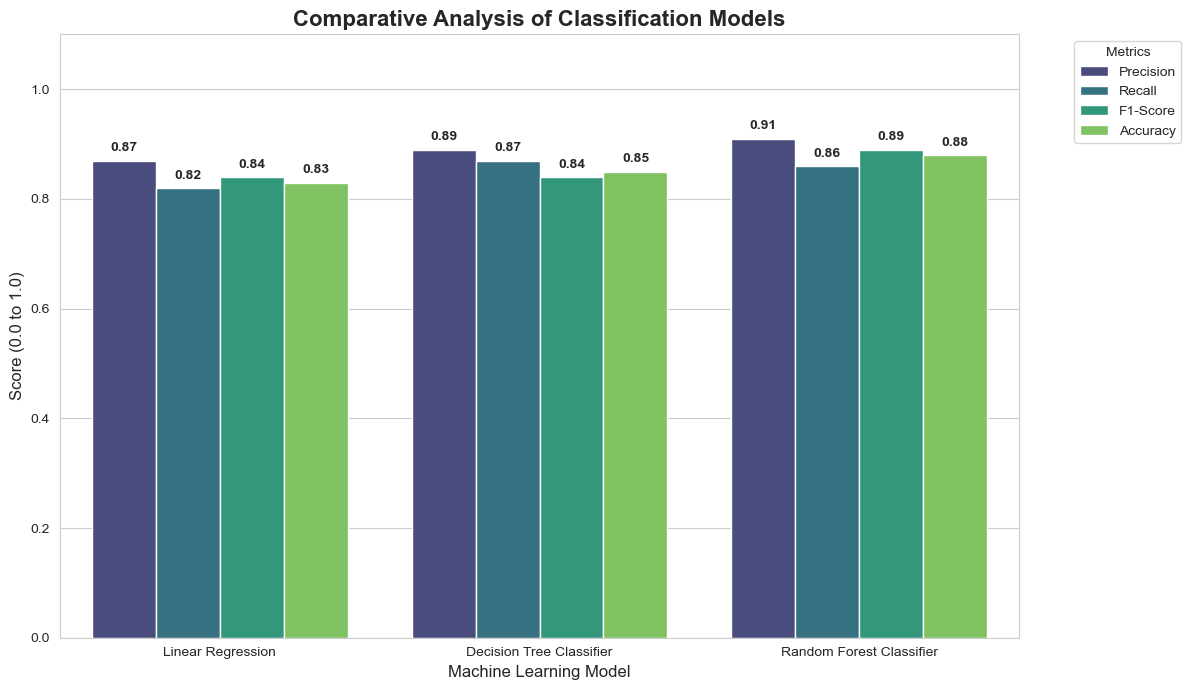

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data based on your classification reports
data = {
    "Model": ["Linear Regression", "Decision Tree Classifier", "Random Forest Classifier"],
    "Precision": [0.87, 0.89, 0.91],
    "Recall": [0.82, 0.87, 0.86],
    "F1-Score": [0.84, 0.84, 0.89],
    "Accuracy": [0.83, 0.85, 0.88]
}

df = pd.DataFrame(data)

# 2. Reshape the data (Melt) so it is compatible with Seaborn's grouped bar chart
df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# 3. Initialize the plot
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 4. Create the bar chart
# 'hue' is what creates the different colored bars for each metric
barplot = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis")

# 5. Add numeric labels on top of each bar for clarity
for p in barplot.patches:
    height = p.get_height()
    if height > 0:
        barplot.annotate(format(height, '.2f'), 
                       (p.get_x() + p.get_width() / 2., height), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=10, fontweight='bold')

# 6. Final visual formatting
plt.title("Comparative Analysis of Classification Models", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1) # Set Y-axis from 0 to 1.1 to give space for labels
plt.ylabel("Score (0.0 to 1.0)", fontsize=12)
plt.xlabel("Machine Learning Model", fontsize=12)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
